In [1]:
import os
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
from glob import glob
from tslearn import barycenters
from scipy.stats import wasserstein_distance
from scipy.signal import detrend
import os.path as op

from kNN_divergence import *

# Add rpy2
%load_ext rpy2.ipython

In [3]:
%%R 

suppressPackageStartupMessages({
    library(broom)
    library(cowplot)
    library(ggpubr)
    library(ggsignif)
    library(glue)
    library(patchwork)
    library(rlist)
    library(see)
    library(tidyverse)
})


# Set cowplot theme
theme_set(theme_cowplot())

In addition: Warning messages:
1: package ‘broom’ was built under R version 4.4.3 
2: package ‘tidyr’ was built under R version 4.4.3 
3: package ‘readr’ was built under R version 4.4.3 


In [4]:
# Define base_repo as one level up from current directory
base_repo = op.dirname(op.abspath(''))
plot_dir = f"{base_repo}/data_visualization/plots/"

# load pyspi SPI info
pyspi_SPI_info = pd.read_csv(f"{base_repo}/functional_connectivity_analysis/pyspi_SPI_info.csv")

# Initialize list for pyspi results
all_pyspi_barycenter_res_averaged_epochs_list = []

# Load pyspi results 
functional_connectivity_measures_dir = f"{base_repo}/data/empirical/functional_connectivity_measures/"
MEG_time_series_dir = f"{base_repo}/data/empirical/MEG_time_series/"
model_sims_dir = f"{base_repo}/data/model/simulated_data/"
model_barycenter_dir = f'{base_repo}/data/model/barycenter_results/'

# Load in pyspi results
# for pyspi_res_file in os.listdir(pyspi_res_path_averaged):
for pyspi_barycenter_res_file in glob(f"{functional_connectivity_measures_dir}/*barycenter_sq*.csv"):
    # Filter to rows where SPI contains the substring 'barycenter'
    pyspi_barycenter_res_averaged = pd.read_csv(pyspi_barycenter_res_file).query("SPI.str.contains('bary')", engine='python')
    all_pyspi_barycenter_res_averaged_epochs_list.append(pyspi_barycenter_res_averaged)

# Specifically filter to bary_euclidean
all_pyspi_barycenter_res_averaged_epochs = pd.concat(all_pyspi_barycenter_res_averaged_epochs_list)

# Separate SPI by whether it ends with _max or _max_time
all_pyspi_barycenter_res_averaged_epochs['SPI_stat'] = np.where(all_pyspi_barycenter_res_averaged_epochs['SPI'].str.contains('_max_time'), 'max_time', 'max')
all_pyspi_barycenter_res_averaged_epochs['SPI'] = all_pyspi_barycenter_res_averaged_epochs['SPI'].str.replace('_max_time', '').str.replace('_max', '')

bary_sq_euclidean_res_averaged_epochs = (all_pyspi_barycenter_res_averaged_epochs
                                         .query("SPI=='bary-sq_euclidean' & relevance_type != 'Relevant target'")
                                         )

In [5]:
# Empirical data
bary_sq_euclidean_res_averaged_epochs = (bary_sq_euclidean_res_averaged_epochs
    .pivot(index=['SPI', 'meta_ROI_from', 'meta_ROI_to', 'Data_Type', 'stimulus_type', 'relevance_type', 'subject_ID', 'stimulus_presentation'],
                                                    columns='SPI_stat', values='value')
    .reset_index()
    .query("meta_ROI_from == 'Category_Selective' & meta_ROI_to in ['Prefrontal_Cortex', 'V1_V2']")
    .assign(Model = lambda x: np.where(x['meta_ROI_to'] == 'Prefrontal_Cortex', 'GNWT', 'IIT'))
    .drop(columns=['meta_ROI_from', 'meta_ROI_to'])
)

# One for raw, one for abs
bary_sq_euclidean_res_averaged_epochs_raw = bary_sq_euclidean_res_averaged_epochs.query("Data_Type=='Raw'")
bary_sq_euclidean_res_averaged_epochs_abs = bary_sq_euclidean_res_averaged_epochs.query("Data_Type=='Abs'")


In [6]:
N_sims = 1000

all_model_pyspi_res_list = []
for noise_level in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    GNWT_stim_on_pyspi_barycenter_res = pd.read_csv(f"{model_barycenter_dir}/GNWT_stim_on_sims_all_pyspi_barycenter_sq_euclidean_results_noise_{noise_level}_params_1.csv")
    GNWT_stim_off_pyspi_barycenter_res = pd.read_csv(f"{model_barycenter_dir}/GNWT_stim_off_sims_all_pyspi_barycenter_sq_euclidean_results_noise_{noise_level}_params_1.csv")
    IIT_stim_on_pyspi_barycenter_res = pd.read_csv(f"{model_barycenter_dir}/IIT_stim_on_sims_all_pyspi_barycenter_sq_euclidean_results_noise_{noise_level}_params_1.csv")
    IIT_stim_off_pyspi_barycenter_res = pd.read_csv(f"{model_barycenter_dir}/IIT_stim_off_sims_all_pyspi_barycenter_sq_euclidean_results_noise_{noise_level}_params_1.csv")

    noise_level_pyspi_res = (pd.concat([GNWT_stim_on_pyspi_barycenter_res,
                                        GNWT_stim_off_pyspi_barycenter_res,
                                        IIT_stim_on_pyspi_barycenter_res,
                                        IIT_stim_off_pyspi_barycenter_res])
                            .query("meta_ROI_from == 'Category_Selective' & SPI in ['bary-sq_euclidean_max', 'bary-sq_euclidean_max_time']")
                            .assign(SPI_stat = lambda x: np.where(x['SPI'].str.contains('_max_time'), 'max_time', 'max'),
                                    SPI = lambda x: x['SPI'].str.replace('_max_time', '').str.replace('_max', ''),
                                    Model = lambda x: x['sim_context'].str.split('_stim').str[0],
                                    stimulus_presentation = lambda x: x['sim_context'].str.split('stim_').str[1])
                            .drop(columns=['sim_context'])
    )

    # Add noise column if it doesn't exist
    if 'Noise' not in noise_level_pyspi_res.columns:
        noise_level_pyspi_res['Noise'] = noise_level
    else:
        noise_level_pyspi_res = noise_level_pyspi_res.query("Noise==@noise_level")

    # Append to list
    all_model_pyspi_res_list.append(noise_level_pyspi_res)

# Concatenate results
all_model_pyspi_res = pd.concat(all_model_pyspi_res_list)


# Filter to bary-sq_euclidean
all_model_pyspi_res_bary_sq_euclidean = (all_model_pyspi_res
                                         .query("SPI=='bary-sq_euclidean'")
                                         .pivot(index=['SPI', 'Noise', 'meta_ROI_from', 'meta_ROI_to', 'Data_Type', 'sim_num', 'param_number', 'Model', 'stimulus_presentation'],
                                                    columns='SPI_stat', values='value')
                                        .reset_index()
                                        .drop(columns=['meta_ROI_from', 'meta_ROI_to'])
)

all_model_pyspi_res_bary_sq_euclidean_raw = all_model_pyspi_res_bary_sq_euclidean.query("Data_Type=='Raw'")
all_model_pyspi_res_bary_sq_euclidean_abs = all_model_pyspi_res_bary_sq_euclidean.query("Data_Type=='Abs'")

In [7]:
all_raw_data_for_comparison = (pd.concat([bary_sq_euclidean_res_averaged_epochs_raw.assign(Data_Type='Empirical'), 
                                         all_model_pyspi_res_bary_sq_euclidean_raw.assign(Data_Type='Model')])
                                         .query("relevance_type == 'Relevant non-target' | Data_Type == 'Model'")
)

all_abs_data_for_comparison = (pd.concat([bary_sq_euclidean_res_averaged_epochs_abs.assign(Data_Type='Empirical'),
                                            all_model_pyspi_res_bary_sq_euclidean_abs.assign(Data_Type='Model')])
                                         .query("relevance_type == 'Relevant non-target' | Data_Type == 'Model'")
)

all_raw_data_for_comparison_irrel = (pd.concat([bary_sq_euclidean_res_averaged_epochs_raw.assign(Data_Type='Empirical'),
                                             all_model_pyspi_res_bary_sq_euclidean_raw.assign(Data_Type='Model')])
                                           .query("relevance_type == 'Irrelevant' | Data_Type == 'Model'")
   )

all_abs_data_for_comparison_irrel = (pd.concat([bary_sq_euclidean_res_averaged_epochs_abs.assign(Data_Type='Empirical'),
                                             all_model_pyspi_res_bary_sq_euclidean_abs.assign(Data_Type='Model')])
                                           .query("relevance_type == 'Irrelevant' | Data_Type == 'Model'")
   )

In [17]:

# Compute the KL divergence between the model and empirical data
all_KL_results_list = []
all_WD_results_list = []
for model in ["GNWT", "IIT"]:
    for noise_level in [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
        for stim_type in ['on', 'off']:
            
            # Subset data
            empirical_data_raw = all_raw_data_for_comparison.query("stimulus_presentation == @stim_type & Model == @model & Data_Type == 'Empirical'")['max_time']
            model_data_raw = all_raw_data_for_comparison.query("stimulus_presentation == @stim_type & Model == @model & Data_Type == 'Model' & Noise==@noise_level")['max_time']
            empirical_data_abs = all_abs_data_for_comparison.query("stimulus_presentation == @stim_type & Model == @model & Data_Type == 'Empirical'")['max_time']
            model_data_abs = all_abs_data_for_comparison.query("stimulus_presentation == @stim_type & Model == @model & Data_Type == 'Model' & Noise==@noise_level")['max_time']

            #### Wasserstein Distance ####
            # Raw data
            this_model_noise_WD_raw = wasserstein_distance(empirical_data_raw, model_data_raw)
            all_WD_results_list.append(pd.DataFrame({"Model": [model], "stimulus_presentation": [stim_type], "Noise": [noise_level], "Data_Type": ["Raw"], "WD": [this_model_noise_WD_raw]}))

            # Absolute value data
            this_model_noise_WD_abs = wasserstein_distance(empirical_data_abs, model_data_abs)
            all_WD_results_list.append(pd.DataFrame({"Model": [model], "stimulus_presentation": [stim_type], "Noise": [noise_level], "Data_Type": ["Abs"], "WD": [this_model_noise_WD_abs]}))

            # Reshape from numpy array to 2D array for kNN estimator
            empirical_data_raw = empirical_data_raw.to_numpy().reshape(-1, 1)
            model_data_raw = model_data_raw.to_numpy().reshape(-1, 1)
            empirical_data_abs = empirical_data_abs.to_numpy().reshape(-1, 1)
            model_data_abs = model_data_abs.to_numpy().reshape(-1, 1)

            #### KL ####

            # We want k=20
            k=20

            # Raw data
            this_model_noise_KL_raw = skl_efficient(s1=empirical_data_raw, s2=model_data_raw, k=k)
            all_KL_results_list.append(pd.DataFrame({"Model": [model], "stimulus_presentation": [stim_type], "Noise": [noise_level], "Data_Type": ["Raw"], "k": [k], "KL_Divergence": [this_model_noise_KL_raw]}))

            # Absolute value data
            this_model_noise_KL_abs = skl_efficient(s1=empirical_data_abs, s2=model_data_abs, k=k)
            all_KL_results_list.append(pd.DataFrame({"Model": [model], "stimulus_presentation": [stim_type], "Noise": [noise_level], "Data_Type": ["Abs"], "k": [k], "KL_Divergence": [this_model_noise_KL_abs]}))

# Concatenate the results
all_KL_results = pd.concat(all_KL_results_list)
all_WD_results = pd.concat(all_WD_results_list)

# Merge the KL and WD results
all_stats_results = pd.merge(all_KL_results, all_WD_results, on=['Model', 'stimulus_presentation', 'Noise', 'Data_Type'])
all_stats_results.query("Noise == 1").sort_values(['Data_Type', 'Model'])

/Users/abry4213/github/MEG_functional_connectivity/barycenter_robustness/kNN_divergence.py:142: RuntimeWarning: divide by zero encountered in log
  D = np.sum(np.log(nu / rho))
/Users/abry4213/github/MEG_functional_connectivity/barycenter_robustness/kNN_divergence.py:142: RuntimeWarning: divide by zero encountered in log
  D = np.sum(np.log(nu / rho))
/Users/abry4213/github/MEG_functional_connectivity/barycenter_robustness/kNN_divergence.py:142: RuntimeWarning: divide by zero encountered in log
  D = np.sum(np.log(nu / rho))
/Users/abry4213/github/MEG_functional_connectivity/barycenter_robustness/kNN_divergence.py:142: RuntimeWarning: divide by zero encountered in log
  D = np.sum(np.log(nu / rho))


,Model,stimulus_presentation,Noise,Data_Type,k,KL_Divergence,WD
21,GNWT,on,1.0,Abs,20,0.085058,40.830255
23,GNWT,off,1.0,Abs,20,0.074754,48.286660
45,IIT,on,1.0,Abs,20,0.105606,18.093830
47,IIT,off,1.0,Abs,20,0.151230,40.791553
20,GNWT,on,1.0,Raw,20,0.023180,14.995468
22,GNWT,off,1.0,Raw,20,-0.018298,19.414957
44,IIT,on,1.0,Raw,20,0.109953,36.371723
46,IIT,off,1.0,Raw,20,0.199237,152.159574


/Users/abry4213/miniforge3/envs/annie_env/lib/python3.10/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '


Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.


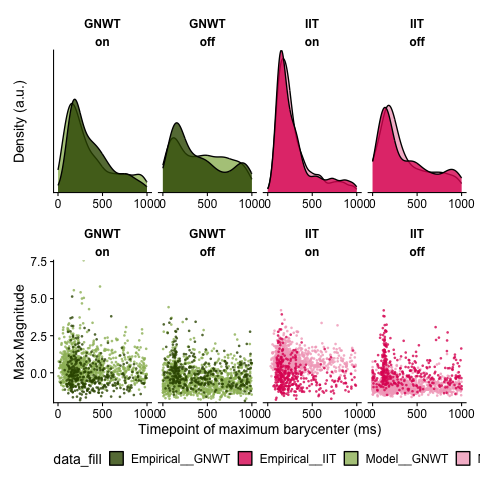

In [28]:
%%R -i all_abs_data_for_comparison,plot_dir -o model_data_for_comparison

model_data_for_comparison <- all_abs_data_for_comparison %>%
    filter(Data_Type=="Model" & Noise==1.0) %>%
    mutate(stimulus_presentation = factor(stimulus_presentation, levels=c("on", "off")),
           data_fill = glue("{Data_Type}__{Model}")) %>%
    group_by(data_fill) %>%
    mutate(Max_Value_Z = (max - mean(max)) / sd(max))

empirical_data_for_comparison <- all_abs_data_for_comparison %>%
    mutate(stimulus_presentation = factor(stimulus_presentation, levels=c("on", "off")),
           data_fill = glue("{Data_Type}__{Model}")) %>%
    group_by(data_fill) %>%
    mutate(Max_Value_Z = (max - mean(max)) / sd(max)) %>%
    filter(Data_Type=="Empirical")

bary_max_density_plot <- ggplot(mapping=aes(x=max_time, fill=data_fill)) +
  scale_x_continuous(expand=c(0,0)) +
    scale_y_continuous(expand=c(0,0)) +
    geom_density(data=model_data_for_comparison, alpha=0.8) +
    geom_density(data=empirical_data_for_comparison, alpha=0.8) +
    facet_wrap(Model ~ stimulus_presentation, scales="free_x", nrow=1) +
    scale_fill_manual(values=c("Empirical__IIT" = "#df2563", "Model__IIT" = "#f3abc3",
                               "Empirical__GNWT" = "#365400", "Model__GNWT" = "#9cba66")) +
    ylab("Density (a.u.)") +
    xlab("Timepoint of maximum barycenter (ms)") +
    theme(axis.text.y = element_blank(),
          axis.ticks.y = element_blank(),
          legend.position="bottom",
          strip.background = element_blank(),
            strip.text.x = element_text(face='bold'),
            strip.text.y = element_text(angle=0, face='bold'))

bary_max_scatter_plot <- ggplot(mapping=aes(x=max_time, y=Max_Value_Z, color=data_fill)) +
  scale_x_continuous(expand=c(0,0)) +
    scale_y_continuous(expand=c(0,0)) +
    geom_point(data=model_data_for_comparison, stroke=0, alpha=0.8, size=1.25) +
    geom_point(data=empirical_data_for_comparison, stroke=0, alpha=0.8, size=1.25) +
    facet_wrap(Model ~ stimulus_presentation, scales="free_x", nrow=1) +
    scale_color_manual(values=c("Empirical__IIT" = "#df2563", "Model__IIT" = "#f3abc3",
                               "Empirical__GNWT" = "#365400", "Model__GNWT" = "#9cba66")) +
    ylab("Max Magnitude") +
    xlab("Timepoint of maximum barycenter (ms)")  +
    theme(legend.position="none",
          strip.background = element_blank(),
            strip.text.x = element_text(face='bold'),
            strip.text.y = element_text(angle=0, face='bold'))

wrap_plots(list(bary_max_density_plot, bary_max_scatter_plot), ncol=1) +
      plot_layout(axis_titles = "collect", guides = "collect") &
      theme(legend.position="bottom") &
      scale_x_continuous(breaks=c(0, 500, 1000), limits=c(0, 1000))

# ggsave(glue("{plot_dir}/modeling/Model_vs_empirical_barycenter_max_timing_abs.svg"), width=8, height=5, units='in', dpi=300)